# Обработка многоцветных изображений: свёрточная сеть для распознавания скорпионов

Лабораторная работа № 4 по дисциплине «Методы машинного обучения».
Московский Политех, группа 231-329, Арутюнян Ф. Р.

**Как я понял задачу.** Вариант по номеру в списке группы (1) это скорпион. Нужен свой набор
цветных изображений, где есть класс «скорпион» и несколько других классов, обучить на нём
свёрточную сеть, показать точность и ошибку на тесте, Precision, Recall и F1 по каждому классу
и примеры распознавания. CIFAR-10 не подходит, класса «скорпион» там нет.

**Набор данных.** Собран скриптом `download_data.py` из открытого API iNaturalist: пять классов
членистоногих, по 500 фотографий на класс. Четыре соседних класса подобраны так, чтобы задача
была содержательной: пауки, многоножки, крабы и жуки снимаются в такой же среде и в таком же
ракурсе, что и скорпионы.

**План работы:**
1. Загрузка набора и просмотр примеров.
2. Предобработка: приведение к одному размеру, нормализация, аугментация.
3. Разбиение на обучающую, валидационную и тестовую выборки.
4. Своя свёрточная сеть: архитектура и обучение.
5. Оценка: точность, ошибка, метрики по классам, матрица ошибок.
6. Примеры верных и ошибочных распознаваний.
7. Улучшение: дообучение предобученной сети ResNet18 и сравнение с собственной.
8. Выводы.

## 0. Библиотеки и устройство

Сеть обучаю в PyTorch. На Mac с чипом M4 доступен ускоритель MPS, он берёт на себя матричные
операции вместо процессора.

In [1]:
import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Устройство:', device)


def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches='tight')

Устройство: mps


## 1. Набор данных

Фотографии лежат в `data/<класс>/`, по папке на класс. `ImageFolder` из torchvision сам
собирает такую структуру в набор и присваивает классам номера по алфавиту.

Если папки `data` нет, её создаёт `python download_data.py 500`.

In [2]:
raw = datasets.ImageFolder('data')
classes = raw.classes
targets = np.array(raw.targets)

counts = pd.Series(targets).value_counts().sort_index()
counts.index = classes
print('Классы и число изображений:')
print(counts)
print('Всего изображений:', len(raw))

sizes = [raw.loader(raw.samples[i][0]).size for i in np.random.choice(len(raw), 200, replace=False)]
print('Размеры файлов (первые 5):', sizes[:5])
print('Медианные ширина и высота:', int(np.median([s[0] for s in sizes])), int(np.median([s[1] for s in sizes])))

Классы и число изображений:
beetle       500
centipede    500
crab         500
scorpion     500
spider       500
Name: count, dtype: int64
Всего изображений: 2500


Размеры файлов (первые 5): [(500, 400), (500, 376), (500, 494), (500, 333), (500, 375)]
Медианные ширина и высота: 500 375


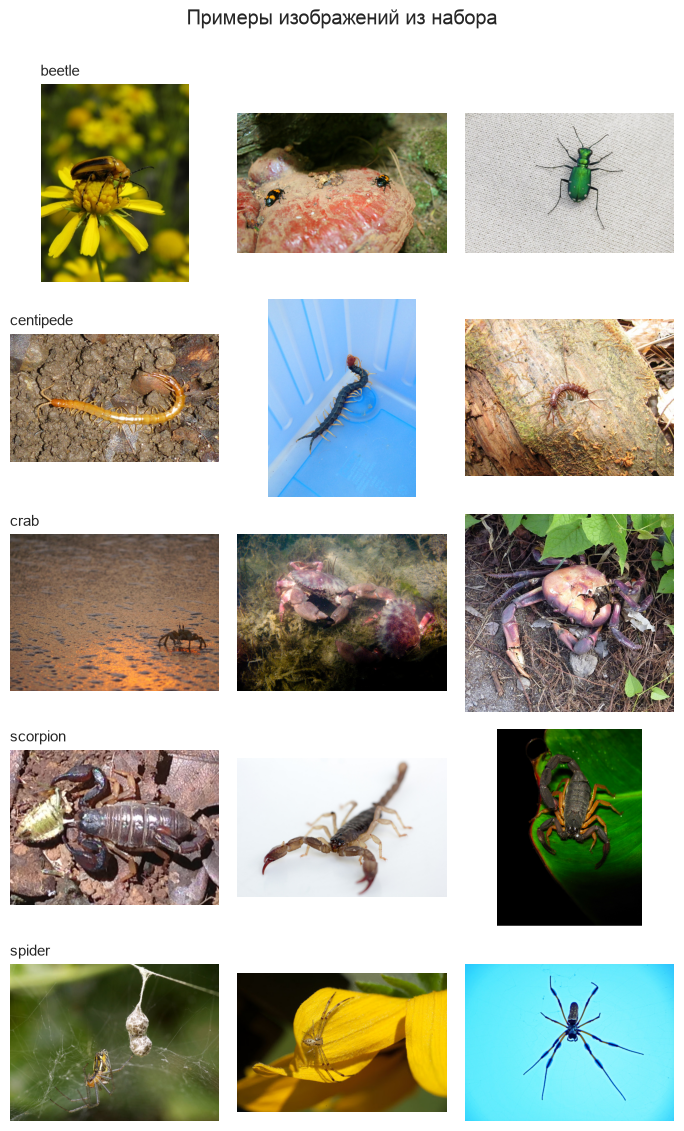

In [3]:
# по три примера каждого класса
fig, axes = plt.subplots(len(classes), 3, figsize=(7, 2.3 * len(classes)))
rng = np.random.RandomState(RANDOM_STATE)
for row, cls in enumerate(classes):
    idx = rng.choice(np.where(targets == row)[0], 3, replace=False)
    for col, i in enumerate(idx):
        axes[row, col].imshow(raw.loader(raw.samples[i][0]))
        axes[row, col].axis('off')
    axes[row, 0].set_title(cls, loc='left', fontsize=11)
fig.suptitle('Примеры изображений из набора', y=1.0)
fig.tight_layout()
save_fig('01_samples.png')
plt.show()

**Рисунок 1 — Примеры изображений каждого класса**

Фотографии сняты в природе: объект часто мелкий, фон пёстрый, освещение разное, поэтому задача сложнее, чем на студийных снимках.

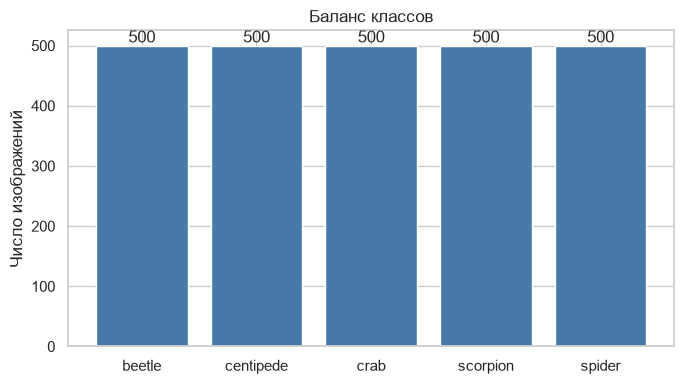

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.index, counts.values, color='#4878a8')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center')
ax.set_ylabel('Число изображений')
ax.set_title('Баланс классов')
fig.tight_layout()
save_fig('02_class_balance.png')
plt.show()

**Рисунок 2 — Баланс классов**

Классы сбалансированы, по 500 изображений, поэтому accuracy сравнима между классами и приёмы против дисбаланса не нужны.

## 2. Предобработка и разбиение

Фотографии из iNaturalist разного размера и пропорций, сеть принимает одинаковые тензоры,
поэтому все изображения привожу к 128 на 128 пикселей и нормализую по средним и отклонениям
ImageNet (они же понадобятся дальше для ResNet18).

Для обучающей части добавляю аугментацию: случайная обрезка с изменением масштаба, отражение
по горизонтали и небольшое изменение яркости и контраста. Аугментация искусственно увеличивает
разнообразие обучающих примеров, поэтому сеть меньше запоминает конкретные фотографии.
К валидации и тесту аугментацию не применяю, там нужна честная оценка.

Разбиение 70 / 15 / 15 со стратификацией по классу: обучающая выборка, валидационная для выбора
лучшей эпохи и тестовая, которую трогаю один раз в конце.

In [5]:
IMG_SIZE = 128
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

ds_train_src = datasets.ImageFolder('data', transform=train_tf)
ds_eval_src = datasets.ImageFolder('data', transform=eval_tf)

idx_all = np.arange(len(targets))
idx_train, idx_rest = train_test_split(idx_all, test_size=0.30, stratify=targets, random_state=RANDOM_STATE)
idx_val, idx_test = train_test_split(idx_rest, test_size=0.50, stratify=targets[idx_rest], random_state=RANDOM_STATE)

train_ds = Subset(ds_train_src, idx_train)
val_ds = Subset(ds_eval_src, idx_val)
test_ds = Subset(ds_eval_src, idx_test)

BATCH = 32
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0)
val_dl = DataLoader(val_ds, batch_size=BATCH, num_workers=0)
test_dl = DataLoader(test_ds, batch_size=BATCH, num_workers=0)

print(f'Обучение {len(train_ds)}, валидация {len(val_ds)}, тест {len(test_ds)}')
print('Классы в тесте:', pd.Series(targets[idx_test]).value_counts().sort_index().tolist())

Обучение 1750, валидация 375, тест 375
Классы в тесте: [75, 75, 75, 75, 75]


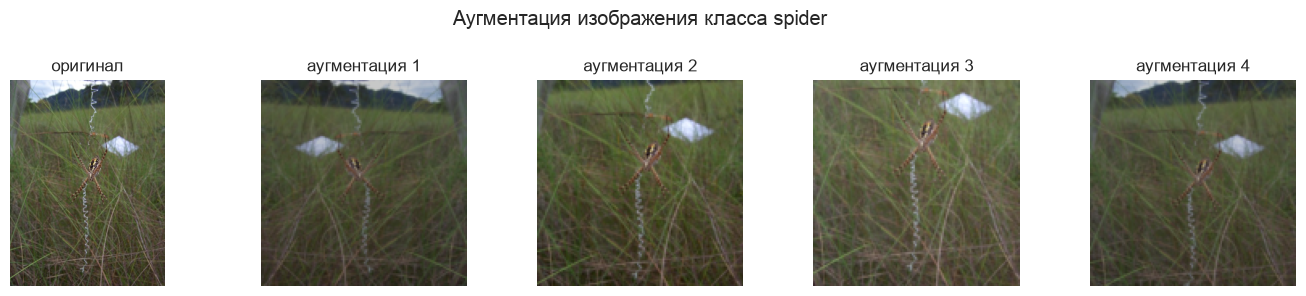

In [6]:
# как выглядит одна и та же картинка после аугментации
i = idx_train[0]
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
axes[0].imshow(raw.loader(raw.samples[i][0]))
axes[0].set_title('оригинал')
axes[0].axis('off')
for k in range(1, 5):
    img = train_tf(raw.loader(raw.samples[i][0])).permute(1, 2, 0).numpy()
    img = np.clip(img * np.array(STD) + np.array(MEAN), 0, 1)
    axes[k].imshow(img)
    axes[k].set_title(f'аугментация {k}')
    axes[k].axis('off')
fig.suptitle(f'Аугментация изображения класса {classes[targets[i]]}')
fig.tight_layout()
save_fig('03_augmentation.png')
plt.show()

**Рисунок 3 — Одно изображение после четырёх случайных аугментаций**

После случайной обрезки, отражения и изменения яркости объект остаётся узнаваемым, но каждый раз попадает в кадр по-новому, поэтому сеть видит один файл как несколько разных примеров.

## 3. Своя свёрточная сеть

Архитектура: четыре одинаковых блока и классификатор.

Блок это свёртка 3 на 3, батч-нормализация, ReLU и max-pooling 2 на 2. Свёртка ищет локальные
признаки (края, пятна, текстуру), батч-нормализация выравнивает распределение активаций и ускоряет
обучение, ReLU обнуляет отрицательные значения и добавляет нелинейность, пулинг уменьшает картинку
вдвое и делает признаки устойчивее к сдвигу.

Число каналов растёт 32, 64, 128, 128: чем глубже слой, тем более сложные сочетания признаков он
описывает. После четырёх блоков картинка 128 на 128 превращается в 8 на 8 с 128 каналами.
Глобальный average pooling сжимает каждую карту признаков в одно число, дропаут гасит 30 % связей
против переобучения, линейный слой выдаёт пять чисел, по одному на класс.

In [7]:
class SmallCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()

        def block(c_in, c_out):
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, kernel_size=3, padding=1),
                nn.BatchNorm2d(c_out),
                nn.ReLU(),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(block(3, 32), block(32, 64), block(64, 128), block(128, 128))
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.head(self.features(x))


cnn = SmallCNN(len(classes)).to(device)
n_params = sum(p.numel() for p in cnn.parameters())
print(cnn)
print(f'Обучаемых параметров: {n_params:,}')

SmallCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): C

### Обучение

Функция потерь CrossEntropyLoss: она сравнивает предсказанное распределение вероятностей классов
с правильным ответом. Оптимизатор Adam с шагом 0,001, каждые 20 эпох шаг уменьшается вдвое.
Учу 60 эпох: на 30 эпохах точность на обучении продолжала расти, значит сеть ещё недоучена.
После каждой эпохи считаю потери и точность на валидации и запоминаю веса лучшей эпохи,
чтобы в конце взять не последнюю модель, а лучшую.

In [8]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Один проход по загрузчику. Если передан optimizer, веса обновляются."""
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.set_grad_enabled(train_mode):
            out = model(x)
            loss = criterion(out, y)
        if train_mode:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


def fit(model, epochs, lr=1e-3, params=None, step=None):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(params if params is not None else model.parameters(), lr=lr)
    # каждые step эпох шаг обучения уменьшается вдвое: сначала быстро, потом аккуратно
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step, gamma=0.5) if step else None
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc, best_state = 0.0, None
    t0 = time.time()
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_dl, criterion)
        for k, v in zip(history, [tr_loss, tr_acc, va_loss, va_acc]):
            history[k].append(v)
        if scheduler:
            scheduler.step()
        if va_acc > best_acc:
            best_acc = va_acc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        print(f'эпоха {ep:2}: потери {tr_loss:.3f}/{va_loss:.3f}, точность {tr_acc:.3f}/{va_acc:.3f}')
    model.load_state_dict(best_state)
    print(f'обучение заняло {time.time() - t0:.0f} с, лучшая точность на валидации {best_acc:.4f}')
    return history


history_cnn = fit(cnn, epochs=60, step=20)

эпоха  1: потери 1.563/1.509, точность 0.260/0.304


эпоха  2: потери 1.501/1.458, точность 0.307/0.331


эпоха  3: потери 1.498/1.457, точность 0.298/0.363


эпоха  4: потери 1.468/1.450, точность 0.339/0.384


эпоха  5: потери 1.438/1.477, точность 0.341/0.349


...

эпоха 56: потери 1.057/1.350, точность 0.594/0.469


эпоха 57: потери 1.072/1.348, точность 0.583/0.483


эпоха 58: потери 1.057/1.342, точность 0.573/0.475


эпоха 59: потери 1.044/1.407, точность 0.594/0.461


эпоха 60: потери 1.045/1.396, точность 0.583/0.456
обучение заняло 367 с, лучшая точность на валидации 0.4827


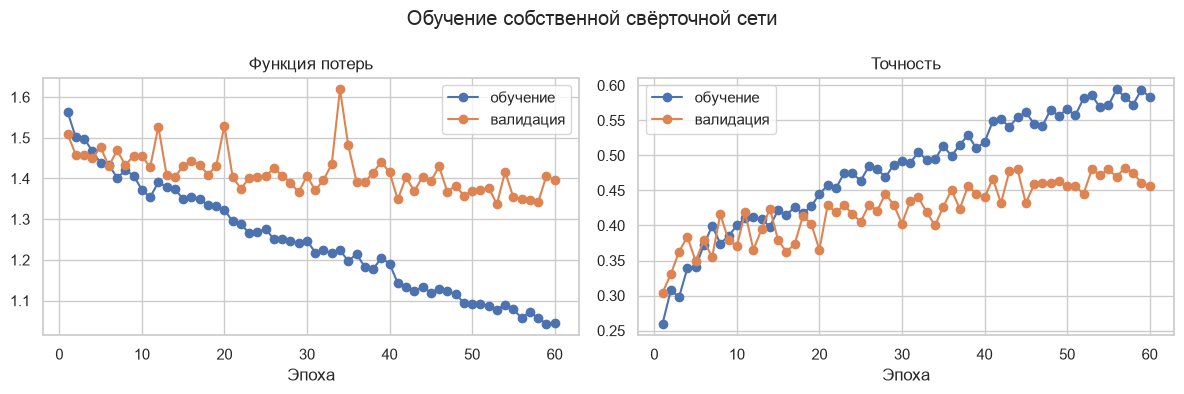

In [9]:
def plot_history(history, title, fname):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ep = range(1, len(history['train_loss']) + 1)
    axes[0].plot(ep, history['train_loss'], 'o-', label='обучение')
    axes[0].plot(ep, history['val_loss'], 'o-', label='валидация')
    axes[0].set_title('Функция потерь')
    axes[0].set_xlabel('Эпоха')
    axes[0].legend()
    axes[1].plot(ep, history['train_acc'], 'o-', label='обучение')
    axes[1].plot(ep, history['val_acc'], 'o-', label='валидация')
    axes[1].set_title('Точность')
    axes[1].set_xlabel('Эпоха')
    axes[1].legend()
    fig.suptitle(title)
    fig.tight_layout()
    save_fig(fname)
    plt.show()


plot_history(history_cnn, 'Обучение собственной свёрточной сети', '04_cnn_training.png')

**Рисунок 4 — Кривые обучения собственной свёрточной сети**

Точность на обучении растёт до 0,583, а на валидации останавливается около 0,46: примерно с 25-й эпохи сеть запоминает обучающие фотографии вместо того, чтобы обобщать, лучшая эпоха дала 0,4827.

## 4. Оценка на тесте

Тестовая выборка при обучении не использовалась. Считаю долю верных ответов, среднюю ошибку
(значение функции потерь) и метрики по каждому классу.

In [10]:
def predict(model, loader):
    """Возвращает настоящие метки, предсказания и вероятности."""
    model.eval()
    ys, preds, probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x.to(device))
            p = torch.softmax(out, dim=1).cpu().numpy()
            probs.append(p)
            preds.append(p.argmax(1))
            ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(preds), np.concatenate(probs)


criterion = nn.CrossEntropyLoss()
test_loss, test_acc = run_epoch(cnn, test_dl, criterion)
y_true, y_pred, y_prob = predict(cnn, test_dl)

print(f'Точность на тесте: {test_acc:.4f}')
print(f'Ошибка (CrossEntropy) на тесте: {test_loss:.4f}\n')
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

Точность на тесте: 0.5013
Ошибка (CrossEntropy) на тесте: 1.3146

              precision    recall  f1-score   support

      beetle     0.4271    0.5467    0.4795        75
   centipede     0.4624    0.5733    0.5119        75
        crab     0.6441    0.5067    0.5672        75
    scorpion     0.5577    0.3867    0.4567        75
      spider     0.4933    0.4933    0.4933        75

    accuracy                         0.5013       375
   macro avg     0.5169    0.5013    0.5017       375
weighted avg     0.5169    0.5013    0.5017       375



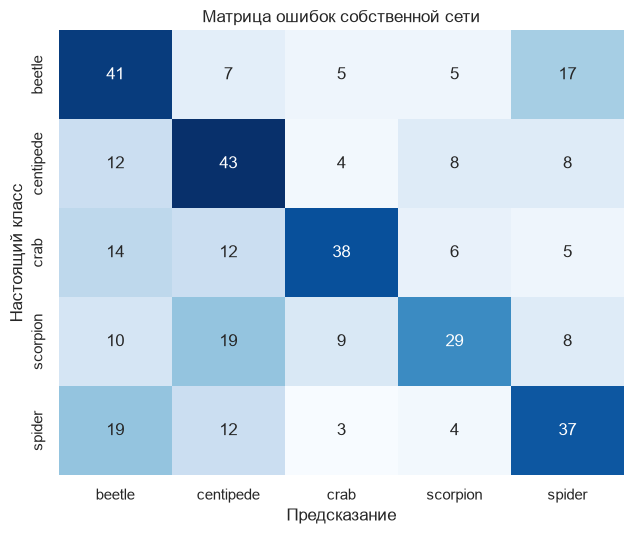

Скорпионы распознаны как: {'beetle': 10, 'centipede': 19, 'crab': 9, 'scorpion': 29, 'spider': 8}


In [11]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Предсказание')
ax.set_ylabel('Настоящий класс')
ax.set_title('Матрица ошибок собственной сети')
fig.tight_layout()
save_fig('05_cnn_confusion.png')
plt.show()

# куда чаще всего уходят скорпионы
sc = classes.index('scorpion')
print('Скорпионы распознаны как:',
      {classes[j]: int(cm[sc, j]) for j in range(len(classes)) if cm[sc, j] > 0})

**Рисунок 5 — Матрица ошибок собственной свёрточной сети**

Скорпионы чаще всего уходят в многоножек (19 из 75), верно распознаны только 29, это худший класс по полноте (0,387).

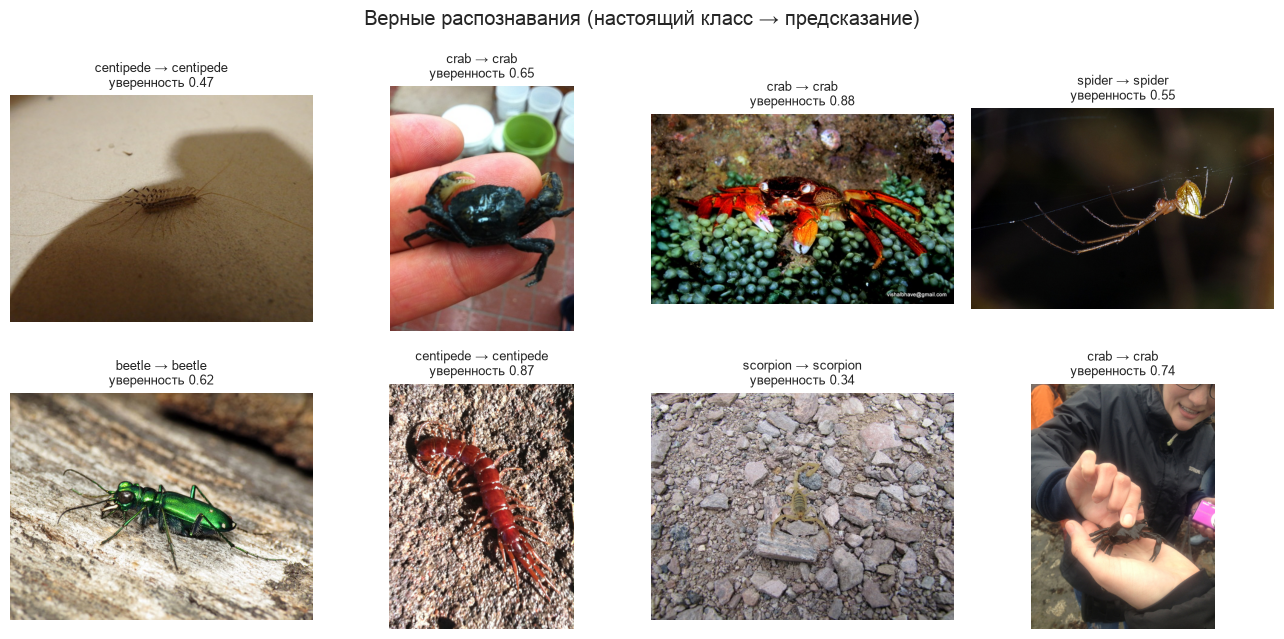

In [12]:
def show_examples(y_true, y_pred, y_prob, idx_pool, correct, fname, title):
    """Сетка примеров: correct=True берёт верные ответы, False ошибочные."""
    mask = (y_true == y_pred) if correct else (y_true != y_pred)
    picks = np.where(mask)[0][:8]
    fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
    for ax, k in zip(axes.ravel(), picks):
        path = raw.samples[idx_pool[k]][0]
        ax.imshow(raw.loader(path))
        ax.axis('off')
        ax.set_title(f'{classes[y_true[k]]} → {classes[y_pred[k]]}\n'
                     f'уверенность {y_prob[k].max():.2f}', fontsize=9)
    for ax in axes.ravel()[len(picks):]:
        ax.axis('off')
    fig.suptitle(title)
    fig.tight_layout()
    save_fig(fname)
    plt.show()


show_examples(y_true, y_pred, y_prob, idx_test, True, '06_correct.png',
              'Верные распознавания (настоящий класс → предсказание)')

**Рисунок 6 — Примеры верных распознаваний**

Верно сеть распознаёт крупные контрастные снимки, где объект занимает почти весь кадр.

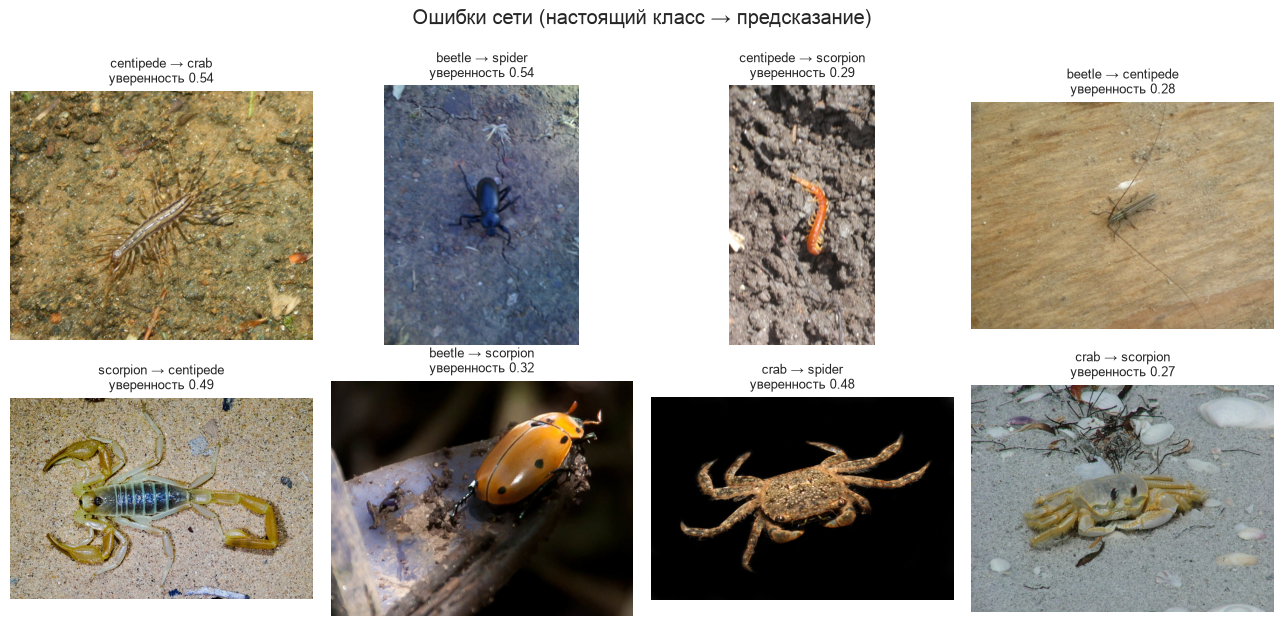

In [13]:
show_examples(y_true, y_pred, y_prob, idx_test, False, '07_errors.png',
              'Ошибки сети (настоящий класс → предсказание)')

**Рисунок 7 — Примеры ошибок сети**

Ошибки собраны на мелких объектах и пёстром фоне: скорпион на песке ушёл в многоножку с уверенностью 0,49, жук на доске в многоножку с уверенностью 0,28.

## 5. Улучшение: дообучение ResNet18

Собственная сеть учится с нуля на 1750 изображениях, этого мало. Приём, который обычно помогает
сильнее всего, называется перенос обучения: берут сеть, обученную на большом наборе ImageNet
(1,2 млн изображений, 1000 классов), и заменяют последний слой на свой.

Замораживаю все свёрточные слои ResNet18 и обучаю только новый линейный слой на пять классов.
Свёртки уже умеют выделять края, текстуру и части объектов, а новому слою нужно лишь научиться
складывать эти признаки в мои пять классов, поэтому хватает нескольких эпох.

In [14]:
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for p in resnet.parameters():
    p.requires_grad = False
resnet.fc = nn.Linear(resnet.fc.in_features, len(classes))
resnet = resnet.to(device)

trainable = [p for p in resnet.parameters() if p.requires_grad]
print(f'Обучаемых параметров: {sum(p.numel() for p in trainable):,} '
      f'из {sum(p.numel() for p in resnet.parameters()):,}')

history_resnet = fit(resnet, epochs=10, lr=1e-3, params=trainable)

Обучаемых параметров: 2,565 из 11,179,077


эпоха  1: потери 1.301/1.065, точность 0.471/0.595


эпоха  2: потери 0.954/0.999, точность 0.646/0.608


эпоха  3: потери 0.850/0.932, точность 0.681/0.632


эпоха  4: потери 0.771/0.911, точность 0.714/0.640


...

эпоха  6: потери 0.748/0.968, точность 0.718/0.635


эпоха  7: потери 0.741/0.922, точность 0.718/0.643


эпоха  8: потери 0.718/0.925, точность 0.739/0.651


эпоха  9: потери 0.693/0.919, точность 0.747/0.651


эпоха 10: потери 0.693/0.907, точность 0.749/0.661
обучение заняло 53 с, лучшая точность на валидации 0.6613


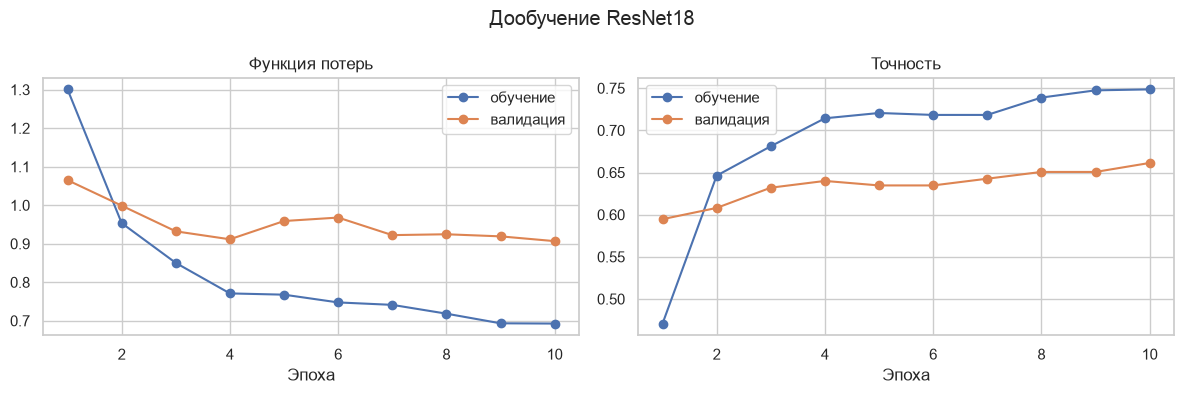

In [15]:
plot_history(history_resnet, 'Дообучение ResNet18', '08_resnet_training.png')

**Рисунок 8 — Кривые обучения дообученной ResNet18**

Точность на валидации выходит на 0,66 уже к четвёртой эпохе и дальше не растёт: обучается только последний слой из 2 565 параметров, остальные 11,2 млн заморожены.

ResNet18: точность на тесте 0.6640, ошибка 0.8765

              precision    recall  f1-score   support

      beetle     0.6719    0.5733    0.6187        75
   centipede     0.7067    0.7067    0.7067        75
        crab     0.6905    0.7733    0.7296        75
    scorpion     0.6410    0.6667    0.6536        75
      spider     0.6081    0.6000    0.6040        75

    accuracy                         0.6640       375
   macro avg     0.6636    0.6640    0.6625       375
weighted avg     0.6636    0.6640    0.6625       375



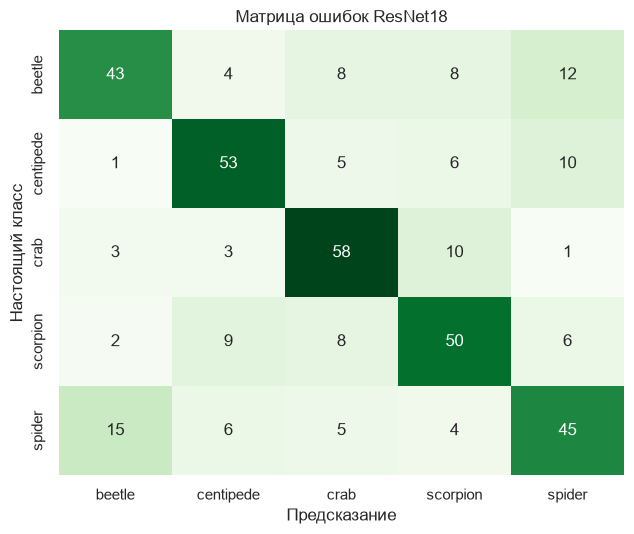

In [16]:
test_loss_r, test_acc_r = run_epoch(resnet, test_dl, criterion)
y_true_r, y_pred_r, y_prob_r = predict(resnet, test_dl)

print(f'ResNet18: точность на тесте {test_acc_r:.4f}, ошибка {test_loss_r:.4f}\n')
print(classification_report(y_true_r, y_pred_r, target_names=classes, digits=4))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
cm_r = confusion_matrix(y_true_r, y_pred_r)
sns.heatmap(cm_r, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Предсказание')
ax.set_ylabel('Настоящий класс')
ax.set_title('Матрица ошибок ResNet18')
fig.tight_layout()
save_fig('09_resnet_confusion.png')
plt.show()

**Рисунок 9 — Матрица ошибок дообученной ResNet18**

ResNet18 ошибается ровнее по классам: полнота от 0,573 у жуков до 0,773 у крабов, скорпионы 0,667 против 0,387 у своей сети.

In [17]:
# сравнение двух сетей по классам
rows = []
for name, yt, yp, acc, loss in [('Своя CNN', y_true, y_pred, test_acc, test_loss),
                                ('ResNet18', y_true_r, y_pred_r, test_acc_r, test_loss_r)]:
    pr, rc, f1, _ = precision_recall_fscore_support(yt, yp, average=None, zero_division=0)
    for i, cls in enumerate(classes):
        rows.append({'Сеть': name, 'Класс': cls, 'Precision': pr[i], 'Recall': rc[i], 'F1': f1[i]})
per_class = pd.DataFrame(rows)

summary = pd.DataFrame({
    'Своя CNN': {'Accuracy': test_acc, 'Ошибка': test_loss,
                 'F1 (macro)': per_class[per_class['Сеть'] == 'Своя CNN']['F1'].mean()},
    'ResNet18': {'Accuracy': test_acc_r, 'Ошибка': test_loss_r,
                 'F1 (macro)': per_class[per_class['Сеть'] == 'ResNet18']['F1'].mean()},
}).T
print(summary.round(4))
per_class.pivot(index='Класс', columns='Сеть', values='F1').round(4)

          Accuracy  Ошибка  F1 (macro)
Своя CNN    0.5013  1.3146      0.5017
ResNet18    0.6640  0.8765      0.6625


Сеть,ResNet18,Своя CNN
Класс,,
beetle,0.6187,0.4795
centipede,0.7067,0.5119
crab,0.7296,0.5672
scorpion,0.6536,0.4567
spider,0.6040,0.4933


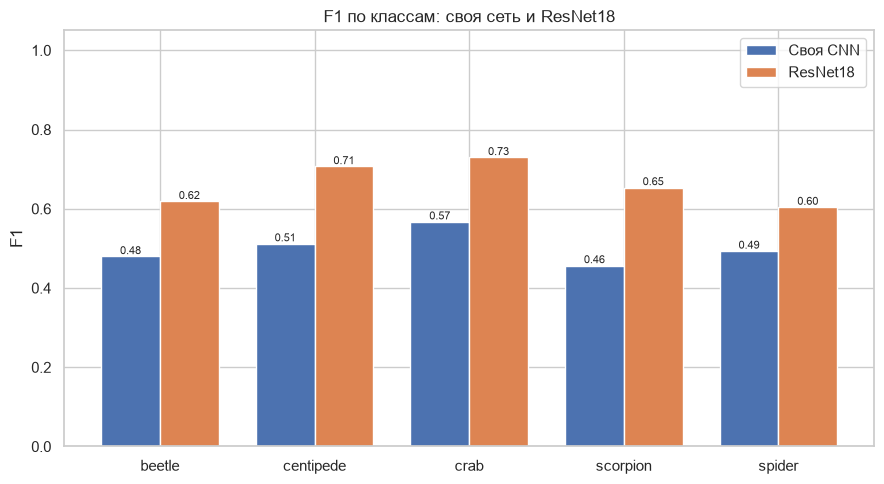

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
width = 0.38
x = np.arange(len(classes))
for k, name in enumerate(['Своя CNN', 'ResNet18']):
    vals = per_class[per_class['Сеть'] == name].set_index('Класс').loc[classes, 'F1']
    bars = ax.bar(x + (k - 0.5) * width, vals, width, label=name)
    ax.bar_label(bars, fmt='%.2f', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel('F1')
ax.set_ylim(0, 1.05)
ax.set_title('F1 по классам: своя сеть и ResNet18')
ax.legend()
fig.tight_layout()
save_fig('10_f1_comparison.png')
plt.show()

**Рисунок 10 — F1 по классам для двух сетей**

Перенос обучения выигрывает на каждом классе, сильнее всего на скорпионах (F1 0,654 против 0,457) и многоножках (0,707 против 0,512).

## 6. Проверка на отдельных изображениях

Беру восемь случайных изображений тестовой выборки и показываю, что о них думает лучшая сеть:
предсказанный класс и вероятность.

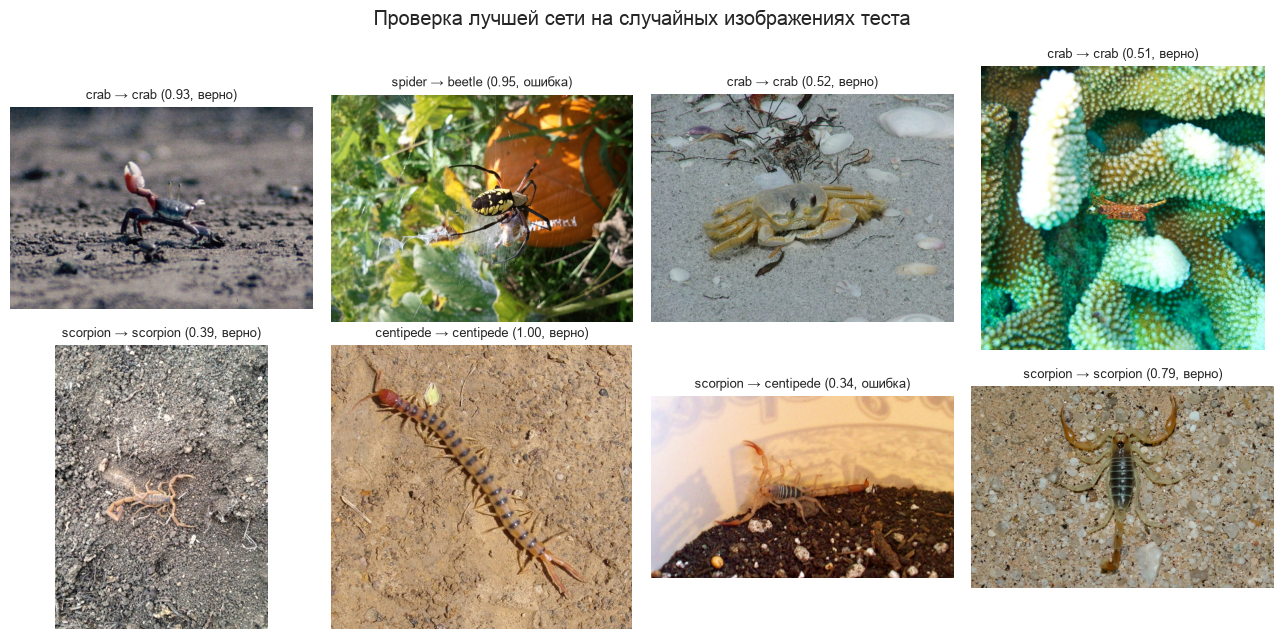

In [19]:
best_model, best_probs = (resnet, y_prob_r) if test_acc_r >= test_acc else (cnn, y_prob)
rng = np.random.RandomState(RANDOM_STATE)
picks = rng.choice(len(idx_test), 8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for ax, k in zip(axes.ravel(), picks):
    ax.imshow(raw.loader(raw.samples[idx_test[k]][0]))
    ax.axis('off')
    p = best_probs[k]
    ok = 'верно' if p.argmax() == y_true[k] else 'ошибка'
    ax.set_title(f'{classes[y_true[k]]} → {classes[p.argmax()]} ({p.max():.2f}, {ok})', fontsize=9)
fig.suptitle('Проверка лучшей сети на случайных изображениях теста')
fig.tight_layout()
save_fig('11_verification.png')
plt.show()

**Рисунок 11 — Проверка лучшей сети на случайных изображениях**

На восьми случайных снимках лучшая сеть ошиблась дважды: паука на фоне листвы приняла за жука с уверенностью 0,95 и мелкого скорпиона в банке за многоножку с уверенностью 0,34.

## 7. Выводы

1. **Набор данных.** Собрано 2500 фотографий пяти классов членистоногих из iNaturalist, по 500 на класс.
   Разбиение 70 / 15 / 15: 1750 изображений на обучение, по 375 на валидацию и тест.

2. **Своя свёрточная сеть** (242 181 параметр, 60 эпох) даёт на тесте точность 0,5013 и ошибку 1,3146,
   macro F1 0,5017. Случайное угадывание при пяти классах дало бы 0,2, то есть сеть чему-то научилась,
   но распознавать изображения с высокой точностью она неспособна. По скорпионам precision 0,558,
   recall 0,387, F1 0,457: почти две трети скорпионов сеть относит к другим классам, чаще всего к многоножкам.

3. **Перенос обучения.** У дообученной ResNet18 точность 0,6640, ошибка 0,8765, macro F1 0,6625.
   Прирост 16,3 процентного пункта, и обучался при этом только последний слой (2 565 параметров против
   11,2 млн замороженных), 53 секунды против 367. По скорпионам F1 вырос с 0,457 до 0,654.

4. **Почему точность невысокая.** Обучающих фотографий мало (350 на класс), объекты на снимках часто
   мелкие и сливаются с фоном (рисунок 7), а разброс внутри класса огромный: крабы сняты и под водой,
   и на песке, скорпионы и на светлом песке, и на тёмной листве. Сжатие до 128 на 128 пикселей убирает
   мелкие детали, по которым скорпион отличается от многоножки, то есть клешни и хвост.

5. **Что улучшило бы результат:** больше изображений на класс, разрешение 224 на 224, разморозка
   последних блоков ResNet18 с маленьким шагом обучения, предварительное выделение объекта на снимке
   детектором, а потом классификация вырезанного фрагмента.